In [1]:
!pip --version
!pipx inject notebook numpy pandas scipy scikit-learn matplotlib
!pipx inject notebook seaborn

pip 24.0 from /usr/lib/python3/dist-packages/pip (python 3.12)
  injected package numpy into venv notebook
done! ✨ 🌟 ✨
  injected package pandas into venv notebook
done! ✨ 🌟 ✨
  injected package scipy into venv notebook
done! ✨ 🌟 ✨
  injected package scikit-learn into venv notebook
done! ✨ 🌟 ✨
  injected package matplotlib into venv notebook
done! ✨ 🌟 ✨
  injected package seaborn into venv notebook
done! ✨ 🌟 ✨


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Starting with Iris dataset 
It was downloaded from the [link](https://archive.ics.uci.edu/dataset/53/iris)

*Need to do the below*
```
Understand Dataset
        ↓
Load Dataset
        ↓
EDA
        ↓
Preprocessing
        ↓
Feature Selection
        ↓
Split Dataset
        ↓
Choose ML Model
        ↓
Evaluate Model
        ↓
Inference
```


## 1)Loading the dataset and analysing basic data of database

In [3]:
column_names=['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']
df=pd.read_csv("iris/iris.data",names=column_names)

print("The shape of the dataset is: ",df.shape)
print("The columns are: ",df.columns)
print("THe info of dataframe is \n",df.info())
df.head()


The shape of the dataset is:  (150, 5)
The columns are:  Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   class         150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB
THe info of dataframe is 
 None


,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## 2) Checking for missing values,duplicate and summary 

In [4]:
print("Checking null\n",df.isnull().sum())
print("\nChecking duplicate values\n",df.duplicated().sum())
print("\nThe summary stat of data is: \n",df.describe())

Checking null
 sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
class           0
dtype: int64

Checking duplicate values
 3

The summary stat of data is: 
        sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


## Observation
- WE can observe no null values are present!
- There are 3 duplicate 
- summary of data is displayed like count,mean,std,etc

## dealing with duplicates:
- remove duplicates

In [5]:
df=df.drop_duplicates()
print(df.duplicated().sum())

0


## Identifying class distribution of iris dataset, then visual representation using histogram and box plot

class
Iris-versicolor    50
Iris-virginica     49
Iris-setosa        48
Name: count, dtype: int64


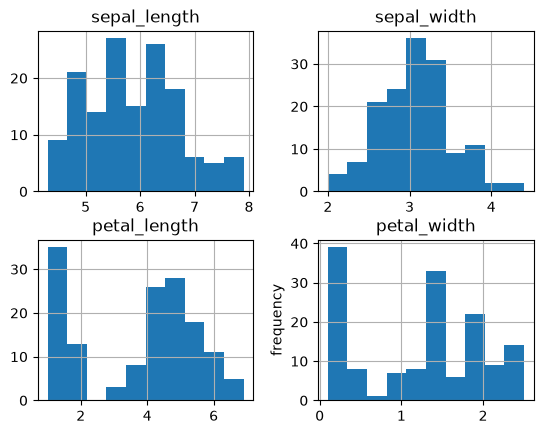

In [6]:
print(df["class"].value_counts())

df.hist()
plt.ylabel("frequency")
plt.show()

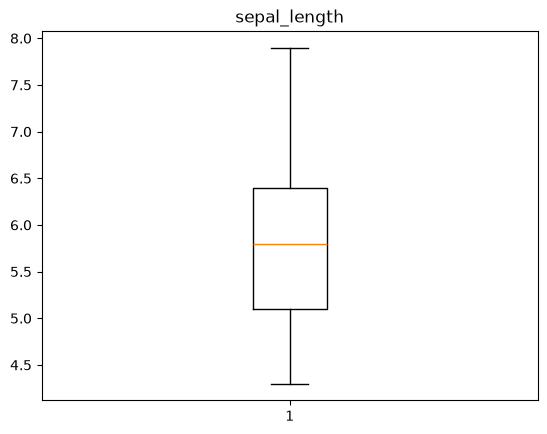

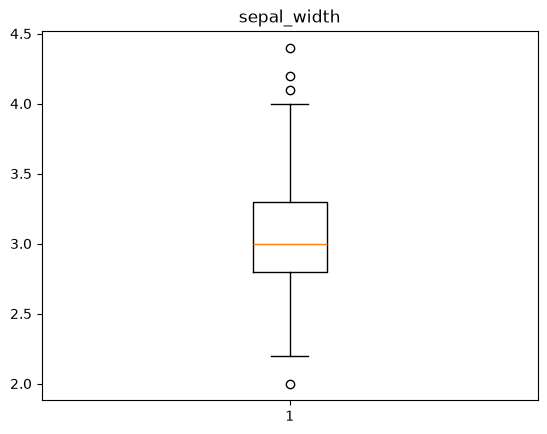

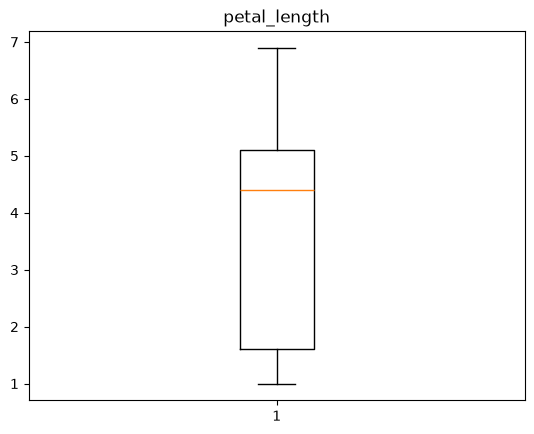

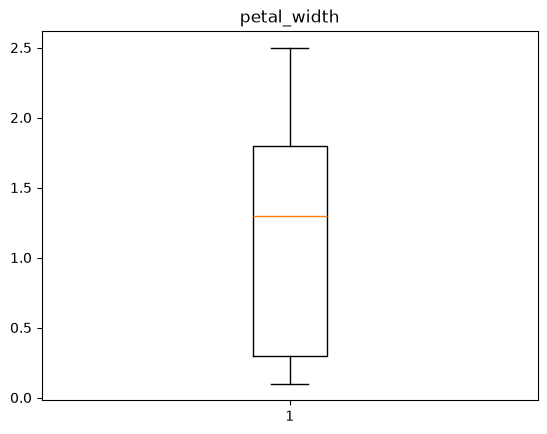

In [7]:
for col in df.columns[:-1]:
    plt.boxplot(df[col])
    plt.title(col)
    plt.show()

## Observation for class distribution:
- We can observe that 3 classes of flowers are present
- They are nearly equally divided, so no need to handle imbalancc 

## Observation from boxplot and histogram
- ### From histogram
  - sepal width has bell shape graph making it closer to normal distribution
  - petal width has 3 peaks with above 22 frequency, and a smaller peak with 10 is freq this indicates that distinct group of flowers have different width
- ### From boxplot
  - Some outliers are present in sepal width
  - Other features are properly distributed around median

## HeatMap 
Helps identify correlation between different features

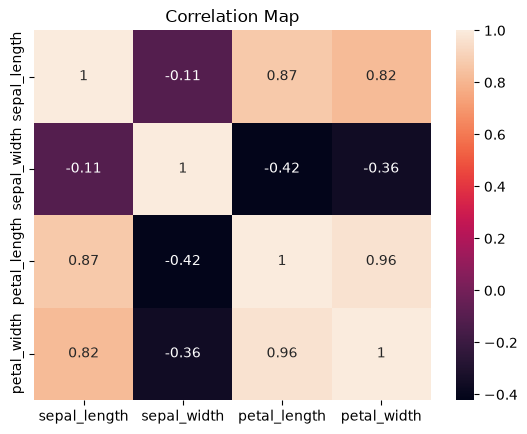

In [8]:
corr=df.iloc[:,:-1].corr()
# print(df.iloc[:,:-1])
sns.heatmap(corr,annot=True)
plt.title("Correlation Map")
plt.show()

## Observation:
- petal width and length have strong positive correlation of .96
- Sepal length and sepal width have bad correlation to each other, score of -.11


## Scatter plot 

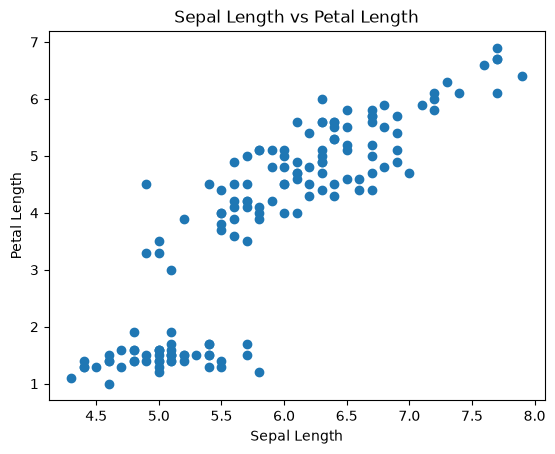

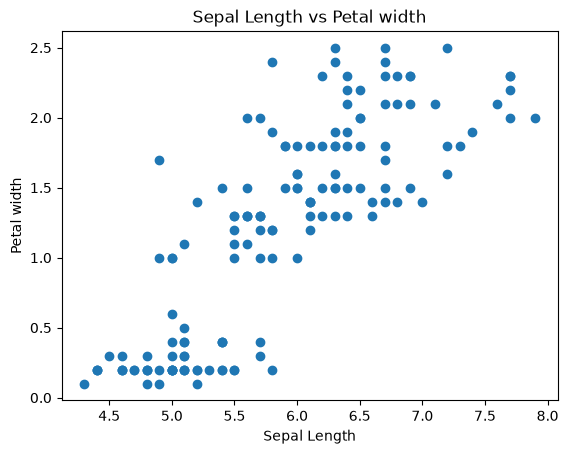

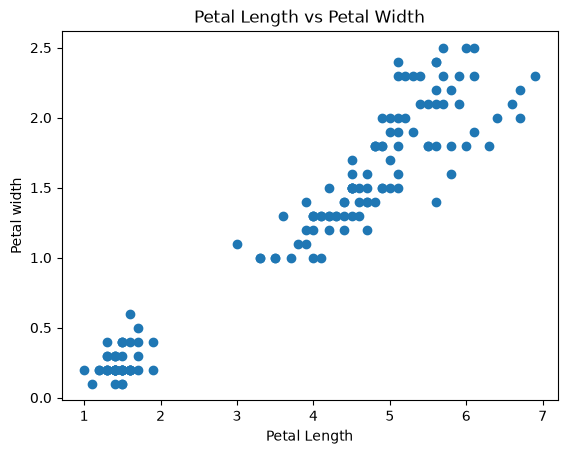

In [9]:
plt.scatter(df["sepal_length"],df["petal_length"])
plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.title("Sepal Length vs Petal Length")
plt.show()

plt.scatter(df["sepal_length"],df["petal_width"])
plt.xlabel("Sepal Length")
plt.ylabel("Petal width")
plt.title("Sepal Length vs Petal width")
plt.show()

plt.scatter(df["petal_length"],df["petal_width"])
plt.xlabel("Petal Length")
plt.ylabel("Petal width")
plt.title("Petal Length vs Petal Width")
plt.show()

## Observation:
- All three relations show positive correlation
- Petal length and petal width show maximum correlation
  

## 1) Handle missing Values


In [10]:
print(df.isnull().sum())

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
class           0
dtype: int64


### Observation:
- WE can see from the output that there is no null/missing elements in any of the features.
- So no further action is needed

# 2)Dropping irrelevant features

In [11]:
print("The columns/features of dataset are: ")
for i in df.columns:
    print(i)


The columns/features of dataset are: 
sepal_length
sepal_width
petal_length
petal_width
class


## Observation:
- All the four features are important in the dataset.
- Since there are no irrelevant features none need to be removed

## 3) Encode categorical Variables
- ml algorithm need numerical values so we convert the categories(target) to numerical equivalent

### Target column contains:
- Iris-setosa
- Iris-versicolor
- Iris-virginica

In [12]:
from sklearn.preprocessing import LabelEncoder

encoder=LabelEncoder()
df["class"]=encoder.fit_transform(df["class"])

In [13]:
print(df.head())

   sepal_length  sepal_width  petal_length  petal_width  class
0           5.1          3.5           1.4          0.2      0
1           4.9          3.0           1.4          0.2      0
2           4.7          3.2           1.3          0.2      0
3           4.6          3.1           1.5          0.2      0
4           5.0          3.6           1.4          0.2      0


In [14]:
print(encoder.classes_)

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


### Observation:
- The target categories were encoded into the numeric equivalent
- The numerical representation are: 0,1,2
- This would allow it to be processed by ml algorithms

# Seperation of features and target

In [15]:
x=df.drop("class",axis=1)
y=df["class"]

In [16]:
print(x.head())
print(y.head())

print(df.head())

   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2
0    0
1    0
2    0
3    0
4    0
Name: class, dtype: int64
   sepal_length  sepal_width  petal_length  petal_width  class
0           5.1          3.5           1.4          0.2      0
1           4.9          3.0           1.4          0.2      0
2           4.7          3.2           1.3          0.2      0
3           4.6          3.1           1.5          0.2      0
4           5.0          3.6           1.4          0.2      0


# Standardization/Normalization
- THis is done so that all features are on similar range of values
- It would help in processing it in ml algorithms

In [23]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
x_temp=scaler.fit_transform(x)

In [31]:
x_scaled=pd.DataFrame(x_temp,columns=x.columns)
print(x_scaled)

print("")
print("mean")
print(x_scaled.mean())
print("\nStandard deviation")
print(x_scaled.std())

     sepal_length  sepal_width  petal_length  petal_width
0       -0.915509     1.019971     -1.357737    -1.335700
1       -1.157560    -0.128082     -1.357737    -1.335700
2       -1.399610     0.331139     -1.414778    -1.335700
3       -1.520635     0.101529     -1.300696    -1.335700
4       -1.036535     1.249582     -1.357737    -1.335700
..            ...          ...           ...          ...
142      1.020892    -0.128082      0.809831     1.444682
143      0.536792    -1.276136      0.695748     0.915085
144      0.778842    -0.128082      0.809831     1.047484
145      0.415766     0.790361      0.923913     1.444682
146      0.052691    -0.128082      0.752789     0.782686

[147 rows x 4 columns]

mean
sepal_length   -4.833624e-17
sepal_width     1.691768e-16
petal_length   -2.416812e-16
petal_width    -3.383537e-16
dtype: float64

Standard deviation
sepal_length    1.003419
sepal_width     1.003419
petal_length    1.003419
petal_width     1.003419
dtype: float64


## Observation:
- Each feature is transformed so that it has mean around 0 and standard deviation=1
- This would help in preventing largetr numerical ranges from dominating learning process